## Load Model Name

In [91]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
import os
import yaml

from deepracer.tracks import TrackIO, Track
from deepracer.tracks.track_utils import track_breakdown, track_meta
from deepracer.logs import \
    SimulationLogsIO as slio, \
    NewRewardUtils as nr, \
    AnalysisUtils as au, \
    PlottingUtils as pu, \
    ActionBreakdownUtils as abu, \
    DeepRacerLog, \
    S3FileHandler, FSFileHandler

# Ignore deprecation warnings we have no power over
import warnings
warnings.filterwarnings('ignore')

In [92]:
bucket_contents = os.listdir('\\\\wsl.localhost\\Ubuntu\\home\\spencer\\deepracer-for-cloud\\data\\minio\\bucket')
bucket_contents.sort()
for thing in bucket_contents:
    print(thing)

2026_01_03_5
2026_01_03_6
2026_01_03_7
2026_01_04_2
2026_01_04_3
2026_01_05_2
2026_01_05_3
2026_01_10_2
2026_02_03_01
2026_02_12_1
2026_02_20_1
custom_files


In [93]:
PREFIX='2026_02_20_1'

In [94]:
#Load Data into dataframe
BUCKET='bucket'       # Bucket name is default 'bucket' when training locally
PROFILE='minio'          # The credentials profile in .aws - 'minio' for local training
## if you are using this notebook in windows and looking for the IP address to access WSL use the command 
# $hostname -I
# If running this notebook within WSL you can use 'http://minio:9000'
S3_ENDPOINT_URL='http://172.29.159.154:9000'
# If you want to pull files from your bucket folder type the address aboove into your browser and change "9000" to "9001"
# e.g. (http://172.22.79.106:9001)
# look up the docker container named miinio... and "inspect"  it to find the credentials to log in.

fh = S3FileHandler(bucket=BUCKET, prefix=PREFIX, profile=PROFILE, s3_endpoint_url=S3_ENDPOINT_URL)
log = DeepRacerLog(filehandler=fh)
log.load_training_trace()
bin_reward = fh.get_file(PREFIX + '/reward_function.py')
bin_reward = bin_reward.decode()
training_paramas = fh.get_file(PREFIX + '/training_params.yaml')
df = log.dataframe()


## Model Hyperparameters, Action Space and Reward Function

In [95]:
# print model info
pprint(log.hyperparameters())
print('----'*25)
pprint(log.action_space())
print('----'*25)
print(bin_reward)

{'batch_size': 64,
 'beta_entropy': 1e-05,
 'discount_factor': 0.9,
 'e_greedy_value': 0.05,
 'epsilon_steps': 10000,
 'exploration_type': 'categorical',
 'loss_type': 'huber',
 'lr': 0.0003,
 'num_episodes_between_training': 20,
 'num_epochs': 5,
 'stack_size': 1,
 'term_cond_avg_score': 350.0,
 'term_cond_max_episodes': 1000}
----------------------------------------------------------------------------------------------------
{'speed': {'high': 3.0, 'low': 1.0}, 'steering_angle': {'high': 25, 'low': -25}}
----------------------------------------------------------------------------------------------------
import math

def getDirection(wp1,wp2) -> float:
    delta_y = wp2[1] - wp1[1]
    delta_x = wp2[0] - wp1[0]
    wp_direction = math.atan2(delta_y,delta_x)
    wp_direction = math.degrees(wp_direction)
    return wp_direction

def getDiff(dir1, dir2) -> float:
    diff = abs(dir1 - dir2)
    if diff > 180:
        diff = 360 - diff
    return diff

def reward_function(params):
    # R

Now let's load the track:

In [96]:
# Load Track Info
tu = TrackIO('C:\\Users\\spenc\\Documents\\Local_Deepracer_Analysis\\tracks')
yaml_params = yaml.safe_load(training_paramas)
training_track = yaml_params['WORLD_NAME']
direction = yaml_params['REVERSE_DIR']
track: Track = tu.load_track(training_track)
print('----'*25)
print(training_track)
if direction == 'True':
    print('Reverse Direction')
else:
    print('Standard Direction')

#pu.plot_trackpoints(track)

Loaded 112 waypoints
----------------------------------------------------------------------------------------------------
reInvent2019_wide
Standard Direction


## Graphs

new reward not found, using reward as its values
Number of episodes =  239
Number of iterations =  11


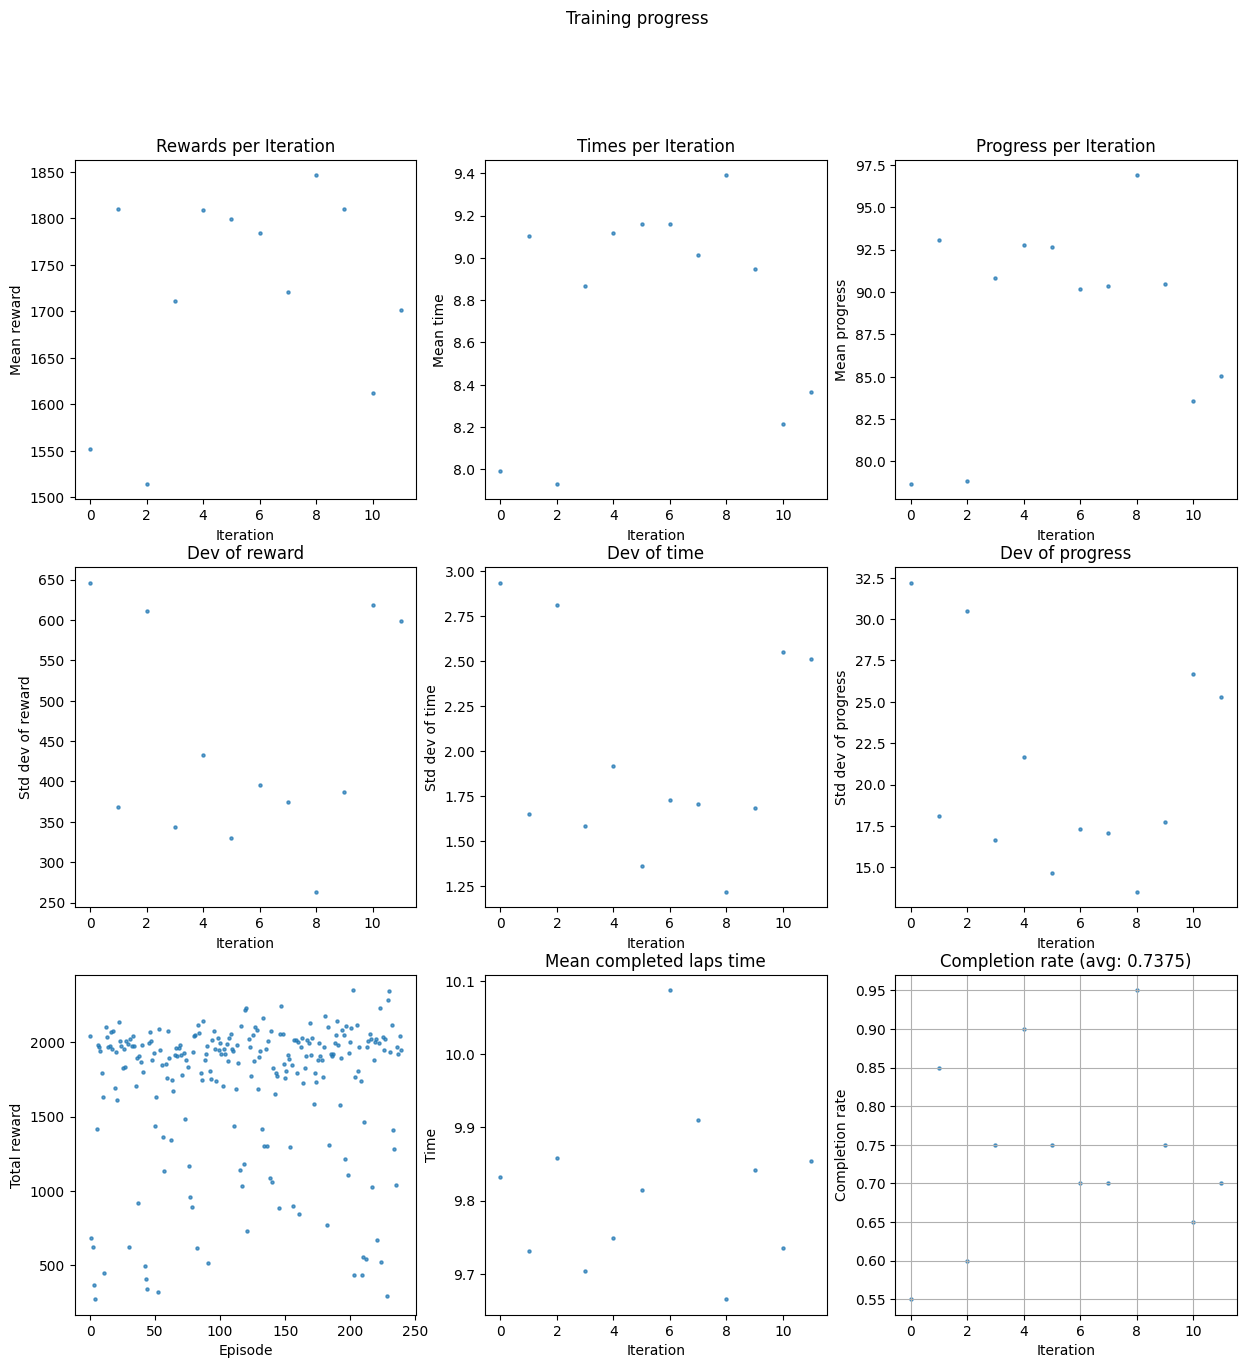

<Figure size 640x480 with 0 Axes>

In [97]:
# Print Core Training Data
simulation_agg = au.simulation_agg(df)
try: 
    if df.nunique(axis=0)['worker'] > 1:
        print("Multiple workers have been detected, reloading data with grouping by unique_episode")
        simulation_agg = au.simulation_agg(df, secondgroup="unique_episode")
except:
    print("Multiple workers not detected, assuming 1 worker")

au.analyze_training_progress(simulation_agg, title='Training progress')

## Track HeatMap

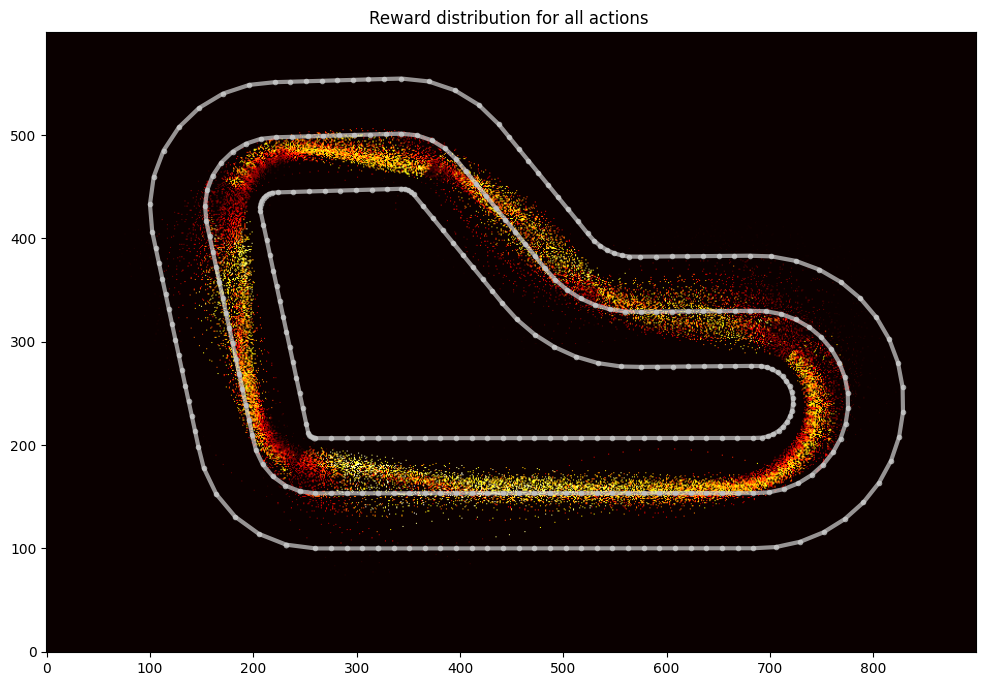

<Figure size 640x480 with 0 Axes>

In [98]:
pu.plot_track(df, track)

### Stats for all laps

Previous graphs were mainly focused on the state of training with regards to training progress. This however will not give you a lot of information about how well your reward function is doing overall.

In such case `scatter_aggregates` may come handy. It comes with three types of graphs:
* progress/steps/reward depending on the time of an episode - of this I find reward/time and new_reward/time especially useful to see that I am rewarding good behaviours - I expect the reward to time scatter to look roughly triangular
* histograms of time and progress - for all episodes the progress one is usually quite handy to get an idea of model's stability
* progress/time_if_complete/reward to closest waypoint at start - these are really useful during training as they show potentially problematic spots on track. It can turn out that a car gets best reward (and performance) starting at a point that just cannot be reached if the car starts elsewhere, or that there is a section of a track that the car struggles to get past and perhaps it's caused by an aggressive action space or undesirable behaviour prior to that place

Side note: `time_if_complete` is not very accurate and will almost always look better for episodes closer to 100% progress than in case of those 50% and below.

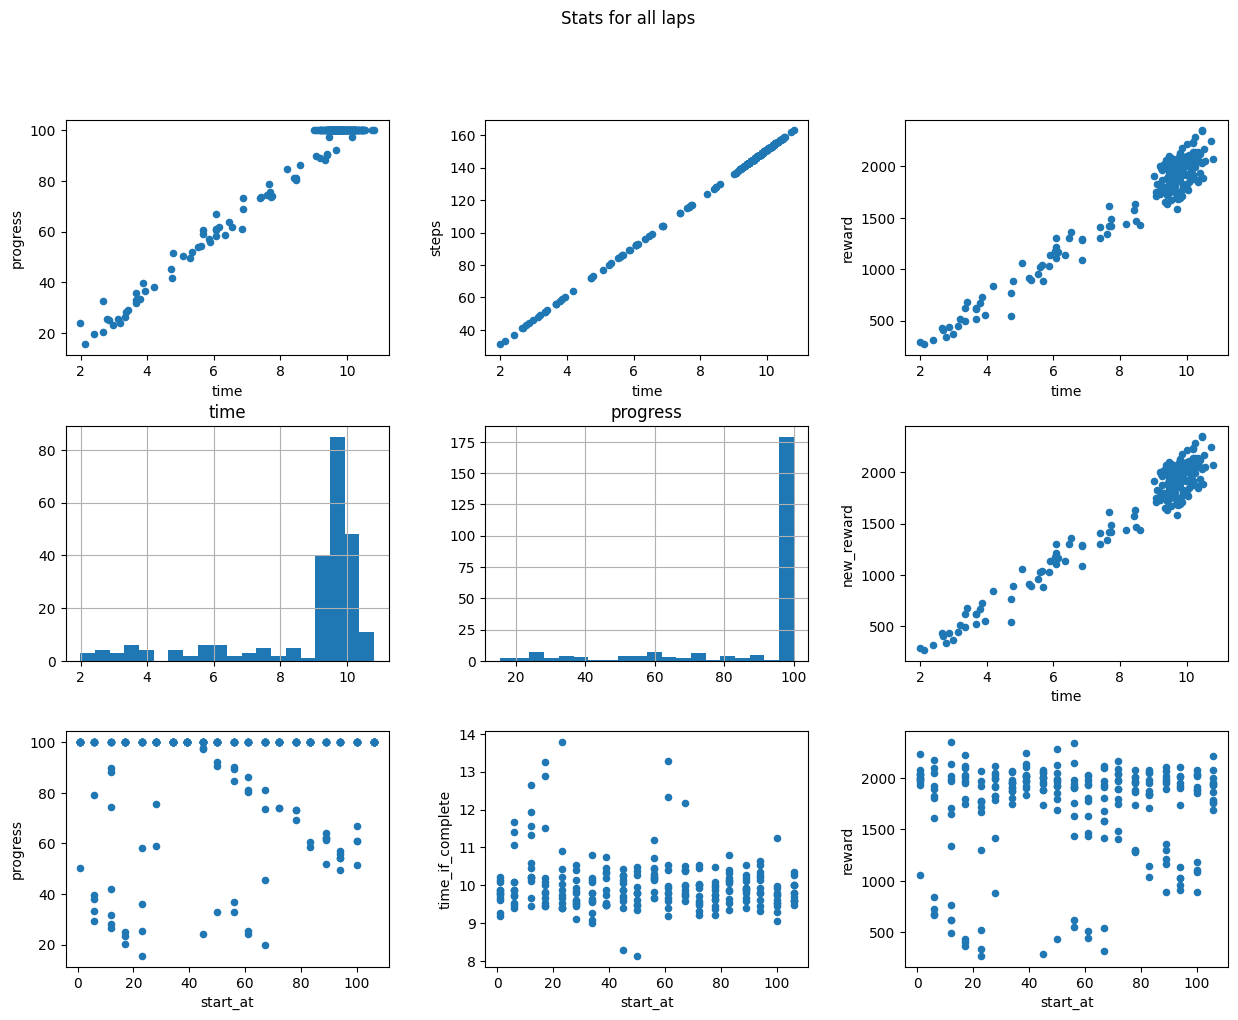

<Figure size 640x480 with 0 Axes>

In [99]:
au.scatter_aggregates(simulation_agg, 'Stats for all laps')

### Stats for complete laps
The graphs here are same as above, but now I am interested in other type of information:
* does the reward scatter show higher rewards for lower completion times? If I give higher reward for a slower lap it might suggest that I am training the car to go slow
* what does the time histogram look like? With enough samples available the histogram takes a normal distribution graph shape. The lower the mean value, the better the chance to complete a fast lap consistently. The longer the tails, the greater the chance of getting lucky in submissions
* is the car completing laps around the place where the race lap starts? Or does it only succeed if it starts in a place different to the racing one?

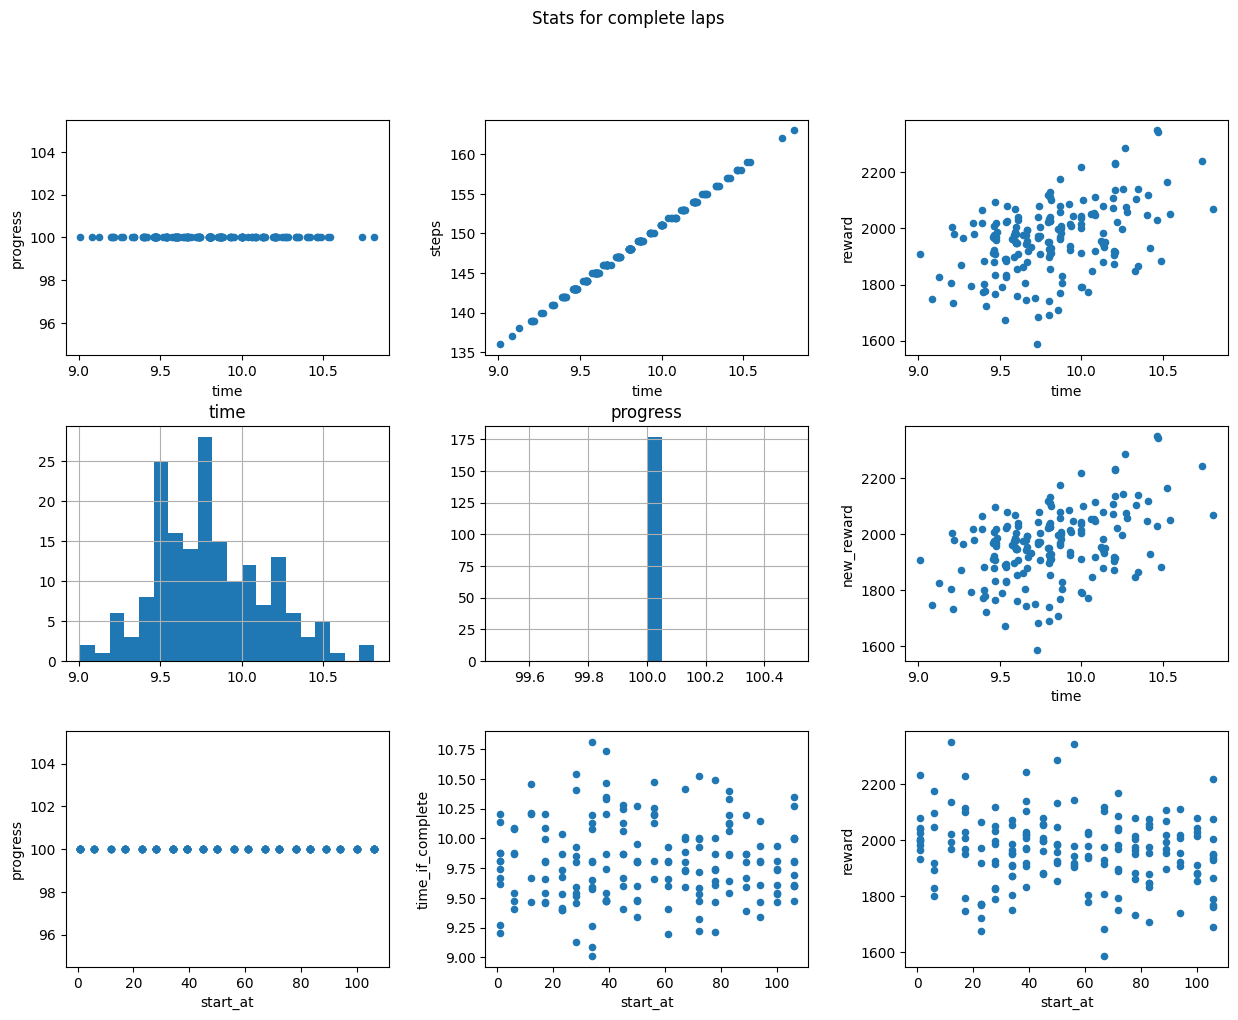

<Figure size 640x480 with 0 Axes>

In [100]:
complete_ones = simulation_agg[simulation_agg['progress']==100]

if complete_ones.shape[0] > 0:
    au.scatter_aggregates(complete_ones, 'Stats for complete laps')
else:
    print('No complete laps yet.')

### Categories analysis
We're going back to comparing training results based on the training time, but in a different way. Instead of just scattering things in relation to iteration or episode number, this time we're grouping episodes based on a certaing information. For this we use function:
```
analyze_categories(panda, category='quintile', groupcount=5, title=None)
```
The idea is pretty simple - determine a way to cluster the data and provide that as the `category` parameter (alongside the count of groups available). In the default case we take advantage of the aggregated information to which quintile an episode belongs and thus build buckets each containing 20% of episodes which happened around the same time during the training. If your training lasted for five hours, this would show results grouped per each hour.

A side note: if you run the function with `category='start_at'` and `groupcount=20` you will get results based on the waypoint closest to the starting point of an episode. If you need to, you can introduce other types of categories and reuse the function.

The graphs are similar to what we've seen above. I especially like the progress one which shows where the model tends to struggle and whether it's successful laps rate is improving or beginning to decrease. Interestingly, I also had cases where I saw the completion drop on the progress rate only to improve in a later quintile, but with a better time graph.

A second side note: if you run this function for `complete_ones` instead of `simulation_agg`, suddenly the time histogram becomes more interesting as you can see whether completion times improve.

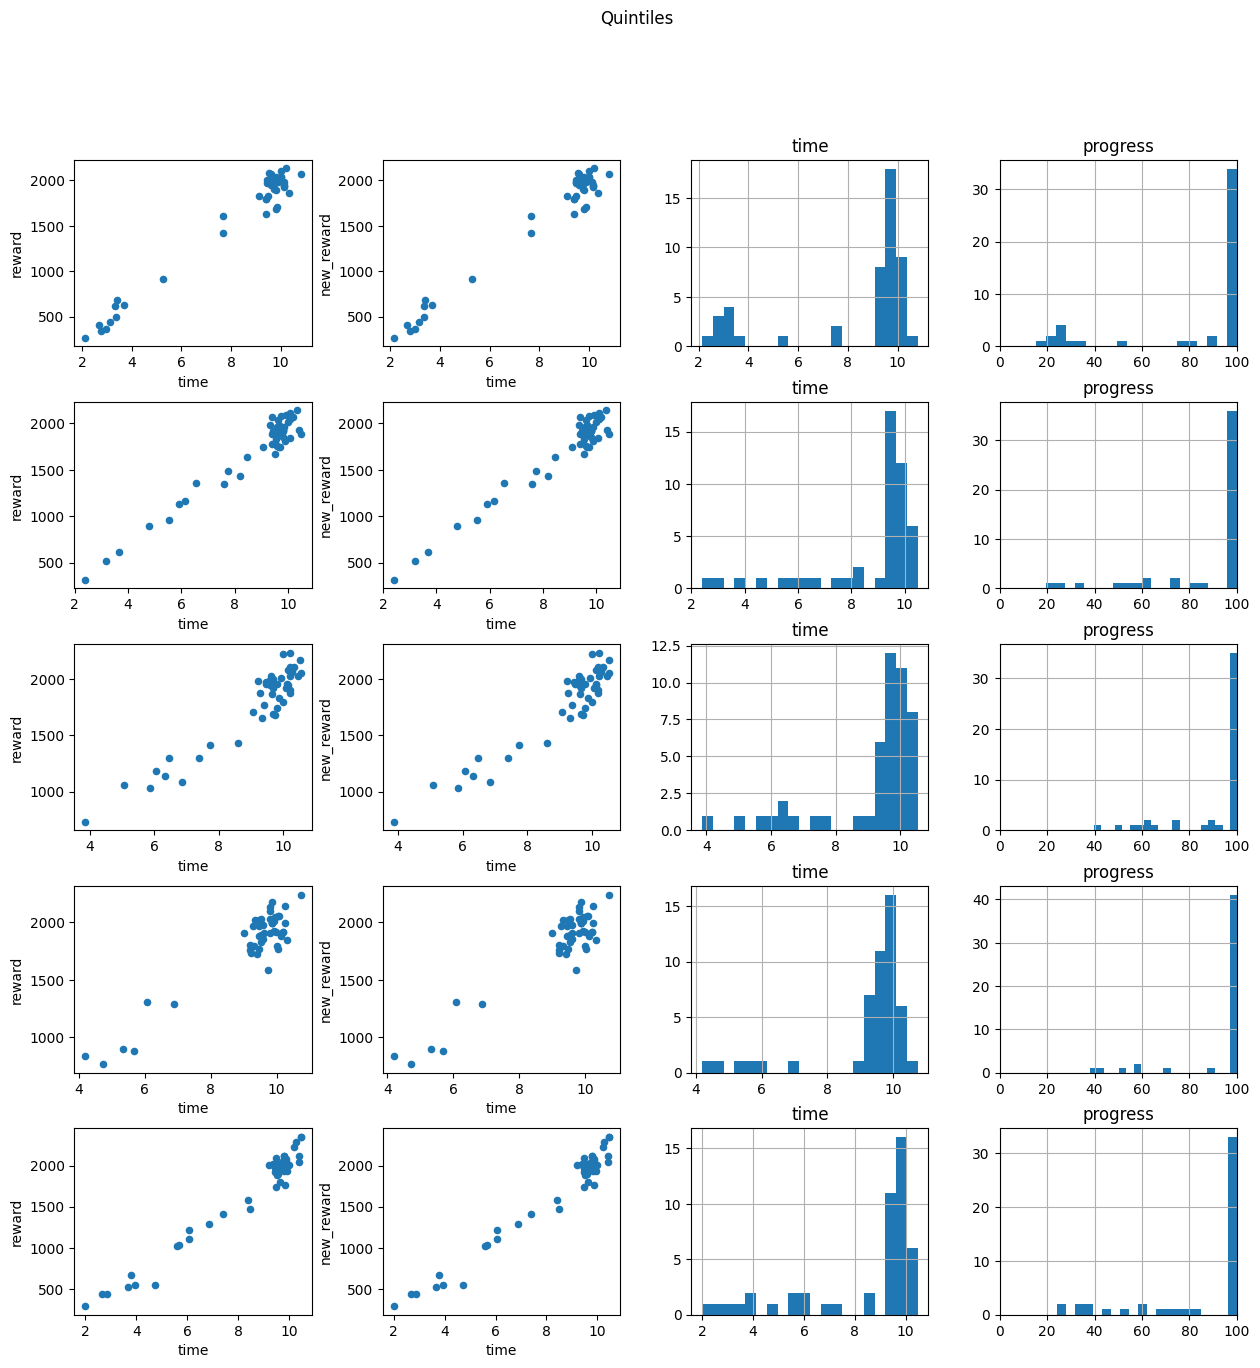

<Figure size 640x480 with 0 Axes>

In [101]:
au.scatter_by_groups(simulation_agg, title='Quintiles')

## Data in tables

While a lot can be seen in graphs that cannot be seen in the raw numbers, the numbers let us get into more detail. Below you will find a couple examples. If your model is behaving the way you would like it to, below tables may provide little added value, but if you struggle to improve your car's performance, they may come handy. In such cases I look for examples where high reward is giving to below-expected episode and when good episodes are given low reward.

You can then take the episode number and scatter it below, and also look at reward given per step - this can in turn draw your attention to some rewarding anomalies and help you detect some unexpected outcomes in your reward function.

There is a number of ways to select the data for display:
* `nlargest`/`nsmallest` lets you display information based on a specific value being highest or lowest
* filtering based on a field value, for instance `df[df['episode']==10]` will display only those steps in `df` which belong to episode 10
* `head()` lets you peek into a dataframe

There isn't a right set of tables to display here and the ones below may not suit your needs. Get to know Pandas more and have fun with them. It's almost as addictive as DeepRacer itself.

The examples have a short comment next to them explaining what they are showing.

In [102]:
# View ten best rewarded episodes in the training
simulation_agg.nlargest(10, 'new_reward')

,iteration,episode,steps,start_at,progress,time,dist,new_reward,speed,reward,time_if_complete,reward_if_complete,quintile,complete
202,10,202,158.0,12,100.0,10.461,15.229329,2349.110140,1.664249,2349.110140,10.461,2349.110140,5th,1
230,11,230,158.0,56,100.0,10.471,15.250369,2342.305081,1.593580,2342.305081,10.471,2342.305081,5th,1
229,11,229,155.0,50,100.0,10.269,15.047592,2285.050856,1.589650,2285.050856,10.269,2285.050856,5th,1
147,7,147,162.0,39,100.0,10.739,15.321415,2241.842016,1.540078,2241.842016,10.739,2241.842016,4th,1
120,6,120,154.0,1,100.0,10.209,14.918125,2233.086966,1.618202,2233.086966,10.209,2233.086966,3rd,1
223,11,223,154.0,17,100.0,10.205,15.060063,2228.324268,1.611028,2228.324268,10.205,2228.324268,5th,1
119,5,119,151.0,106,100.0,10.001,14.866269,2218.922032,1.624027,2218.922032,10.001,2218.922032,3rd,1
181,9,181,149.0,6,100.0,9.868,14.947990,2174.208919,1.671978,2174.208919,9.868,2174.208919,4th,1
133,6,133,159.0,72,100.0,10.526,14.739616,2166.480835,1.513291,2166.480835,10.526,2166.480835,3rd,1
190,9,190,155.0,56,100.0,10.258,15.079890,2141.820058,1.588329,2141.820058,10.258,2141.820058,4th,1


In [103]:
# View five fastest complete laps
complete_ones.nsmallest(5, 'time')

,iteration,episode,steps,start_at,progress,time,dist,new_reward,speed,reward,time_if_complete,reward_if_complete,quintile,complete
186,9,186,136.0,34,100.0,9.011,15.622467,1909.533118,1.832315,1909.533118,9.011,1909.533118,4th,1
86,4,86,137.0,34,100.0,9.083,15.140639,1749.426548,1.721973,1749.426548,9.083,1749.426548,2nd,1
25,1,25,138.0,28,100.0,9.125,15.652565,1826.442590,1.783950,1826.442590,9.125,1826.442590,1st,1
151,7,151,139.0,61,100.0,9.200,14.700274,1804.185080,1.691881,1804.185080,9.200,1804.185080,4th,1
200,10,200,139.0,1,100.0,9.205,15.136673,2003.807490,1.816738,2003.807490,9.205,2003.807490,5th,1


In [104]:
# View five best rewarded completed laps
complete_ones.nlargest(5, 'reward')

,iteration,episode,steps,start_at,progress,time,dist,new_reward,speed,reward,time_if_complete,reward_if_complete,quintile,complete
202,10,202,158.0,12,100.0,10.461,15.229329,2349.110140,1.664249,2349.110140,10.461,2349.110140,5th,1
230,11,230,158.0,56,100.0,10.471,15.250369,2342.305081,1.593580,2342.305081,10.471,2342.305081,5th,1
229,11,229,155.0,50,100.0,10.269,15.047592,2285.050856,1.589650,2285.050856,10.269,2285.050856,5th,1
147,7,147,162.0,39,100.0,10.739,15.321415,2241.842016,1.540078,2241.842016,10.739,2241.842016,4th,1
120,6,120,154.0,1,100.0,10.209,14.918125,2233.086966,1.618202,2233.086966,10.209,2233.086966,3rd,1


In [105]:
# View five best rewarded in completed laps (according to new_reward if you are using it)
complete_ones.nlargest(5, 'new_reward')

,iteration,episode,steps,start_at,progress,time,dist,new_reward,speed,reward,time_if_complete,reward_if_complete,quintile,complete
202,10,202,158.0,12,100.0,10.461,15.229329,2349.110140,1.664249,2349.110140,10.461,2349.110140,5th,1
230,11,230,158.0,56,100.0,10.471,15.250369,2342.305081,1.593580,2342.305081,10.471,2342.305081,5th,1
229,11,229,155.0,50,100.0,10.269,15.047592,2285.050856,1.589650,2285.050856,10.269,2285.050856,5th,1
147,7,147,162.0,39,100.0,10.739,15.321415,2241.842016,1.540078,2241.842016,10.739,2241.842016,4th,1
120,6,120,154.0,1,100.0,10.209,14.918125,2233.086966,1.618202,2233.086966,10.209,2233.086966,3rd,1


In [106]:
# View five most progressed episodes
simulation_agg.nlargest(5, 'progress')

,iteration,episode,steps,start_at,progress,time,dist,new_reward,speed,reward,time_if_complete,reward_if_complete,quintile,complete
0,0,0,148.0,1,100.0,9.810,15.097010,2041.628397,1.691350,2041.628397,9.810,2041.628397,1st,1
6,0,6,153.0,34,100.0,10.132,15.556811,1984.389074,1.650985,1984.389074,10.132,1984.389074,1st,1
7,0,7,147.0,39,100.0,9.745,15.292870,1971.760010,1.691096,1971.760010,9.745,1971.760010,1st,1
12,0,12,151.0,67,100.0,10.008,15.648424,2102.196109,1.649732,2102.196109,10.008,2102.196109,1st,1
13,0,13,151.0,72,100.0,10.001,15.376225,2036.722369,1.621325,2036.722369,10.001,2036.722369,1st,1


In [107]:
# View information for a couple first episodes
simulation_agg.head()

,iteration,episode,steps,start_at,progress,time,dist,new_reward,speed,reward,time_if_complete,reward_if_complete,quintile,complete
0,0,0,148.0,1,100.000000,9.810,15.097010,2041.628397,1.691350,2041.628397,9.810000,2041.628397,1st,1
1,0,1,52.0,6,29.209285,3.412,5.102116,679.775450,1.892632,679.775450,11.681217,2327.258100,1st,0
2,0,2,51.0,12,26.367806,3.336,4.516812,622.849396,1.692776,622.849396,12.651792,2362.158621,1st,0
3,0,3,46.0,17,23.184985,2.986,3.988646,365.675554,1.561461,365.675554,12.879025,1577.208530,1st,0
4,0,4,33.0,23,15.459224,2.130,2.806202,269.859601,1.542442,269.859601,13.778182,1745.621899,1st,0


In [108]:
# Set maximum quantity of rows to view for a dataframe display - without that
# the view below will just hide some of the steps
pd.set_option('display.max_rows', 500)

# View all steps data for episode 10
df[df['episode']==10]

,episode,steps,x,y,heading,steering_angle,speed,action,reward,done,...,track_len,tstamp,episode_status,pause_duration,iteration,worker,unique_episode,delta_time,delta_dist,new_reward
1041,10,1.0,4.276943,3.102479,147.696288,3.954172,1.788839,[3.9541719336191257 1.788838644620919],0.000000,False,...,16.635021,78.660,prepare,0.0,0,0,10,0.000,0.000000,0.000000
1042,10,2.0,4.277110,3.102501,147.667753,-25.000000,2.341501,[-25.0 2.3415006382534367],11.505038,False,...,16.635021,78.725,in_progress,0.0,0,0,10,0.065,0.000168,11.505038
1043,10,3.0,4.270643,3.106717,147.729584,-25.000000,2.030522,[-25.0 2.030522018656149],11.076170,False,...,16.635021,78.791,in_progress,0.0,0,0,10,0.066,0.007719,11.076170
1044,10,4.0,4.254499,3.127135,145.621899,-24.155510,2.814613,[-24.155509690258082 2.814613202081944],12.714012,False,...,16.635021,78.866,in_progress,0.0,0,0,10,0.075,0.026030,12.714012
1045,10,5.0,4.227334,3.164441,141.943973,3.861091,1.322684,[3.8610911530771723 1.322684493977004],13.090068,False,...,16.635021,78.929,in_progress,0.0,0,0,10,0.063,0.046148,13.090068
1046,10,6.0,4.181935,3.199481,141.873760,-25.000000,2.213411,[-25.0 2.2134112974102425],13.891529,False,...,16.635021,78.993,in_progress,0.0,0,0,10,0.064,0.057349,13.891529
1047,10,7.0,4.126492,3.246192,141.249700,-13.959877,1.417766,[-13.959877302330675 1.417766384587466],12.998408,False,...,16.635021,79.064,in_progress,0.0,0,0,10,0.071,0.072497,12.998408
1048,10,8.0,4.087843,3.303533,136.538119,-9.730167,2.230751,[-9.730167404332063 2.2307513016338705],17.096432,False,...,16.635021,79.142,in_progress,0.0,0,0,10,0.078,0.069150,17.096432
1049,10,9.0,4.035091,3.390022,130.888739,-25.000000,3.000000,[-25.0 3.0],22.344489,False,...,16.635021,79.197,in_progress,0.0,0,0,10,0.055,0.101307,22.344489
1050,10,10.0,3.995419,3.480395,124.383612,23.136483,3.000000,[23.136482803919044 3.0],15.723890,False,...,16.635021,79.263,in_progress,0.0,0,0,10,0.066,0.098697,15.723890


## Analyze the reward distribution for your reward function

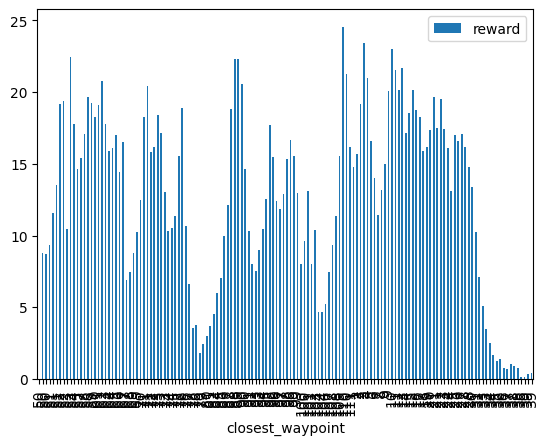

In [109]:
# This shows a histogram of actions per closest waypoint for episode 889.
# Will let you spot potentially problematic places in reward granting.
# In this example reward function is clearly `return 1`. It may be worrying
# if your reward function has some logic in it.
# If you have a final step reward that makes the rest of this histogram
# unreadable, you can filter the last step out by using
# `episode[:-1].plot.bar` instead of `episode.plot.bar`
episode = df[df['episode']==9]

if episode.empty:
    print("You probably don't have episode with this number, try a lower one.")
else:
    episode.plot.bar(x='closest_waypoint', y='reward')

### Path taken for top reward iterations

NOTE: at some point in the past in a single episode the car could go around multiple laps, the episode was terminated when car completed 1000 steps. Currently one episode has at most one lap. This explains why you can see multiple laps in an episode plotted below.

Being able to plot the car's route in an episode can help you detect certain patterns in its behaviours and either promote them more or train away from them. While being able to watch the car go in the training gives some information, being able to reproduce it after the training is much more practical.

Graphs below give you a chance to look deeper into your car's behaviour on track.

We start with plot_selected_laps. The general idea of this block is as follows:
* Select laps(episodes) that have the properties that you care about, for instance, fastest, most progressed, failing in a certain section of the track or not failing in there,
* Provide the list of them in a dataframe into the plot_selected_laps, together with the whole training dataframe and the track info,
* You've got the laps to analyse.

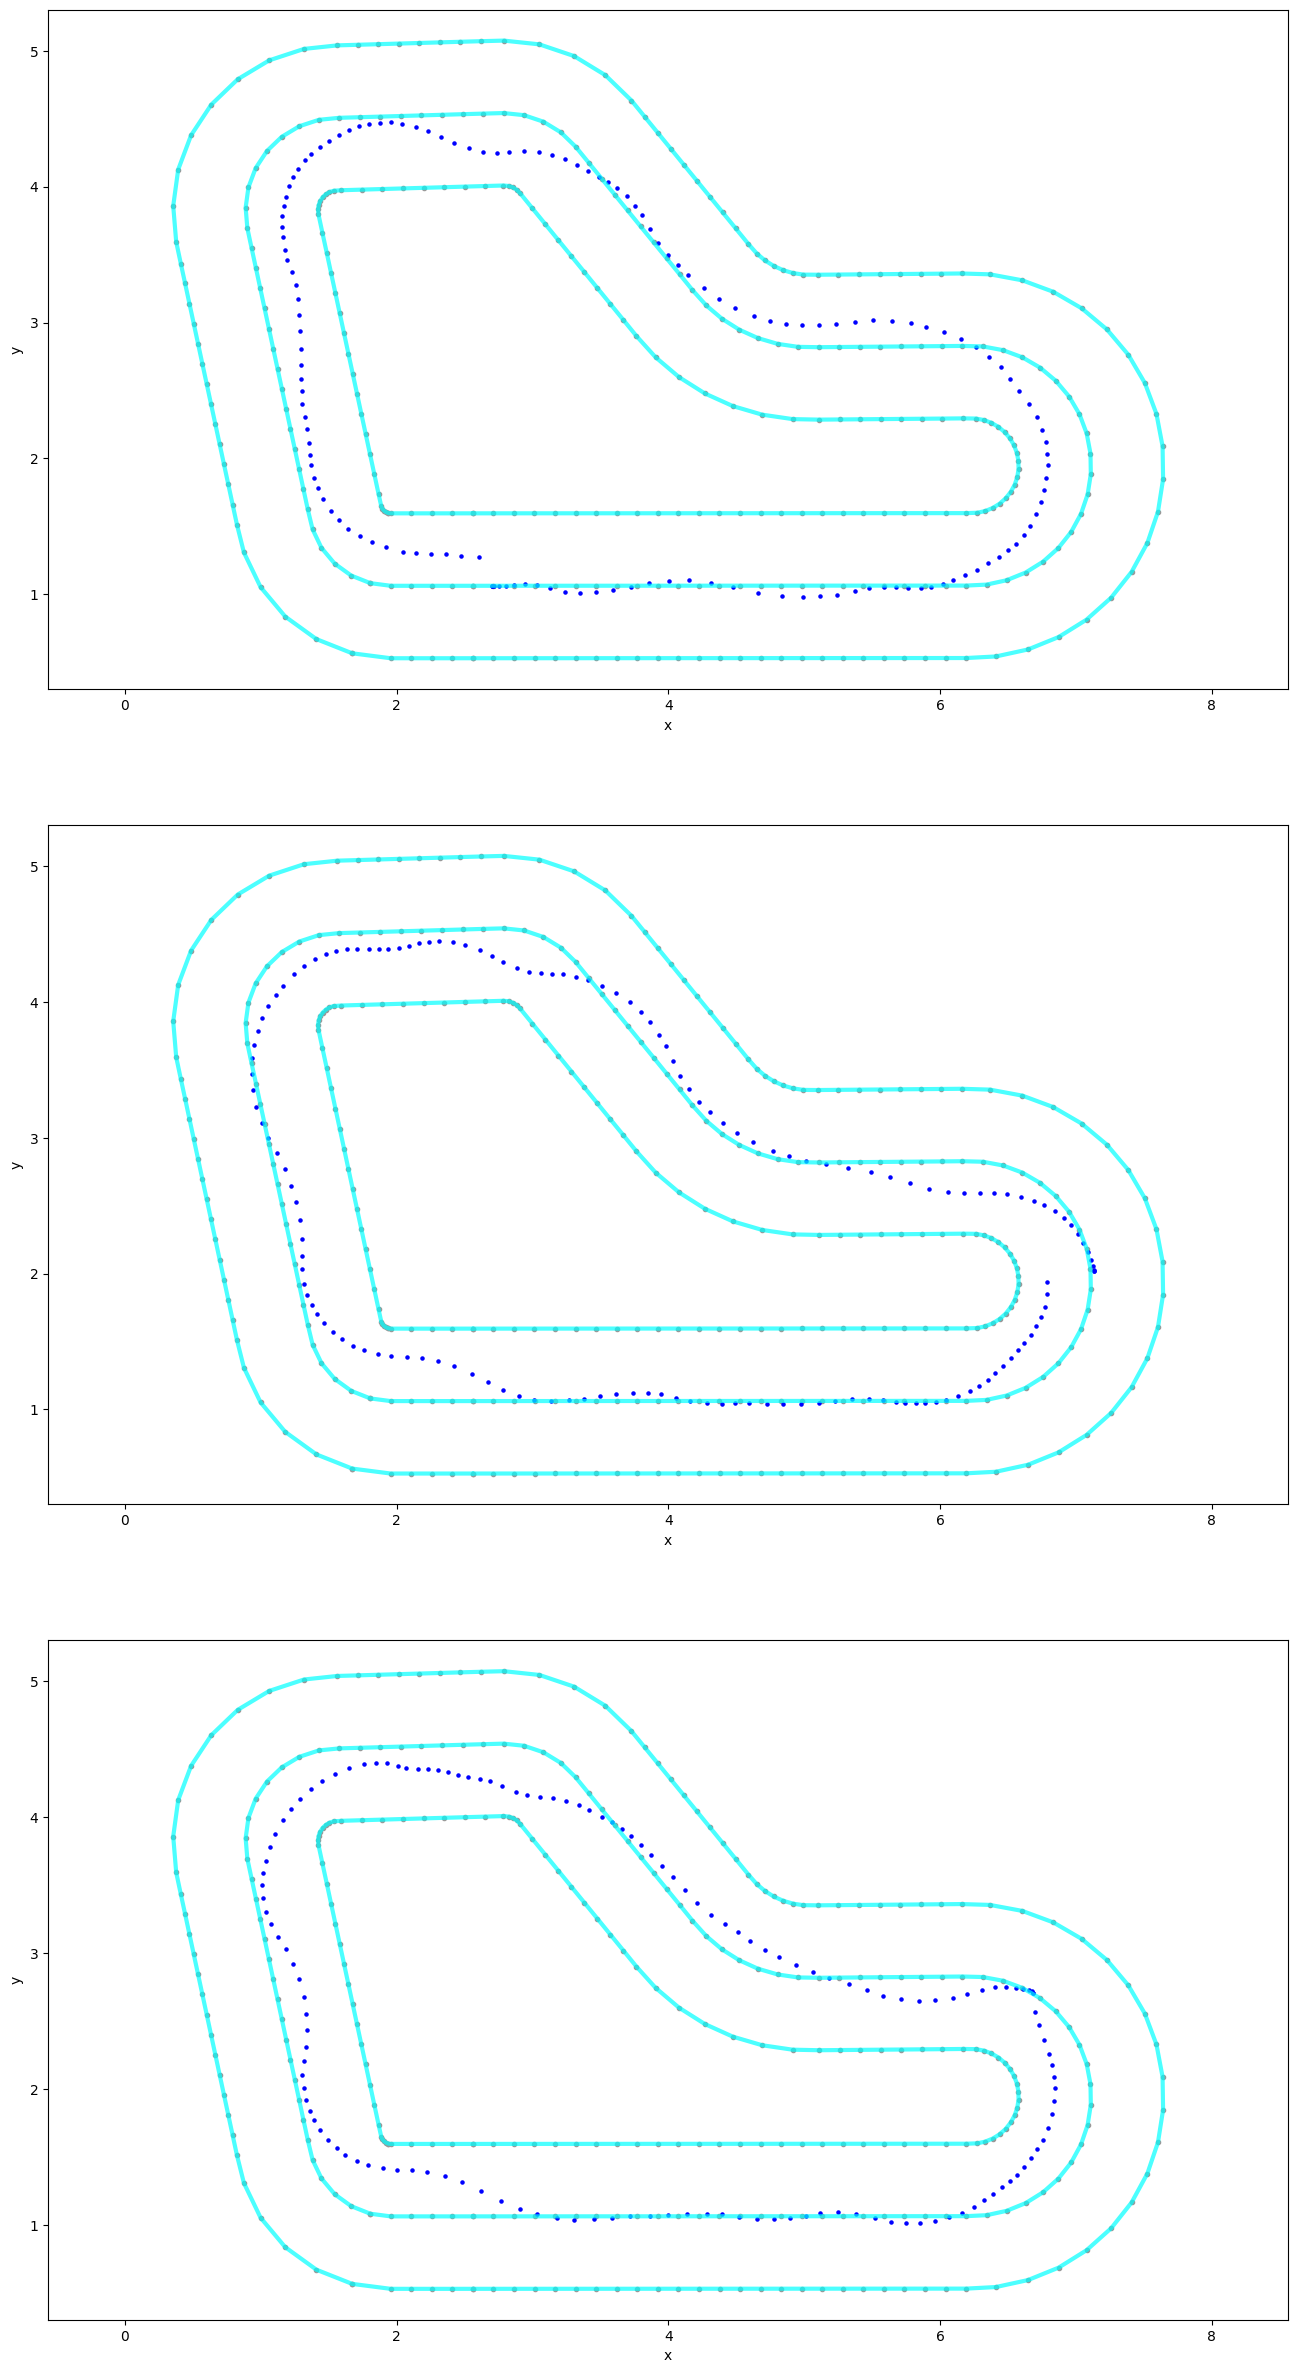

<Figure size 640x480 with 0 Axes>

In [110]:
# Some examples:
# highest reward for complete laps:
# episodes_to_plot = complete_ones.nlargest(3,'reward')

# highest progress from all episodes:
episodes_to_plot = simulation_agg.nlargest(3,'progress')

try:
    if df.nunique(axis=0)['worker'] > 1:
        pu.plot_selected_laps(episodes_to_plot, df, track, section_to_plot="unique_episode")
    else:
        pu.plot_selected_laps(episodes_to_plot, df, track)
except:
    print("Multiple workers not detected, assuming 1 worker")
    pu.plot_selected_laps(episodes_to_plot, df, track)

### Plot a heatmap of rewards for current training. 
The brighter the colour, the higher the reward granted in given coordinates.
If instead of a similar view as in the example below you get a dark image with hardly any 
dots, it might be that your rewards are highly disproportionate and possibly sparse.

Disproportion means you may have one reward of 10.000 and the rest in range 0.01-1.
In such cases the vast majority of dots will simply be very dark and the only bright dot
might be in a place difficult to spot. I recommend you go back to the tables and show highest
and average rewards per step to confirm if this is the case. Such disproportions may
not affect your traning very negatively, but they will make the data less readable in this notebook.

Sparse data means that the car gets a high reward for the best behaviour and very low reward
for anything else, and worse even, reward is pretty much discrete (return 10 for narrow perfect,
else return 0.1). The car relies on reward varying between behaviours to find gradients that can
lead to improvement. If that is missing, the model will struggle to improve.

### Plot a particular iteration
This is same as the heatmap above, but just for a single iteration.

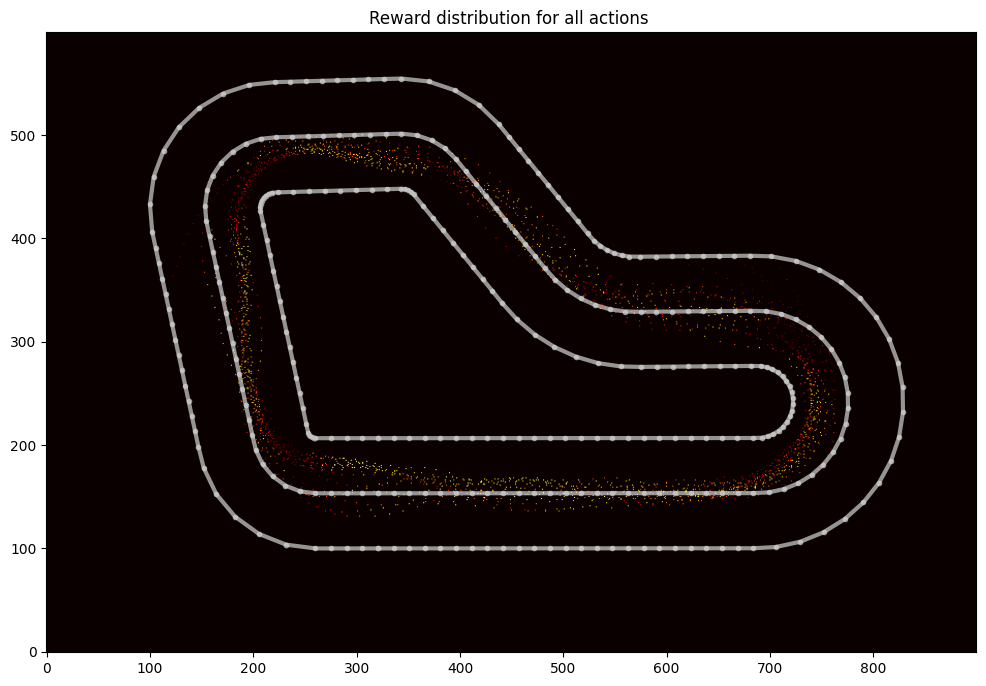

<Figure size 640x480 with 0 Axes>

In [111]:
#If you'd like some other colour criterion, you can add
#a value_field parameter and specify a different column
iteration_id = 3

pu.plot_track(df[df['iteration'] == iteration_id], track)

### Path taken in a particular episode

In [112]:
episode_id = 12

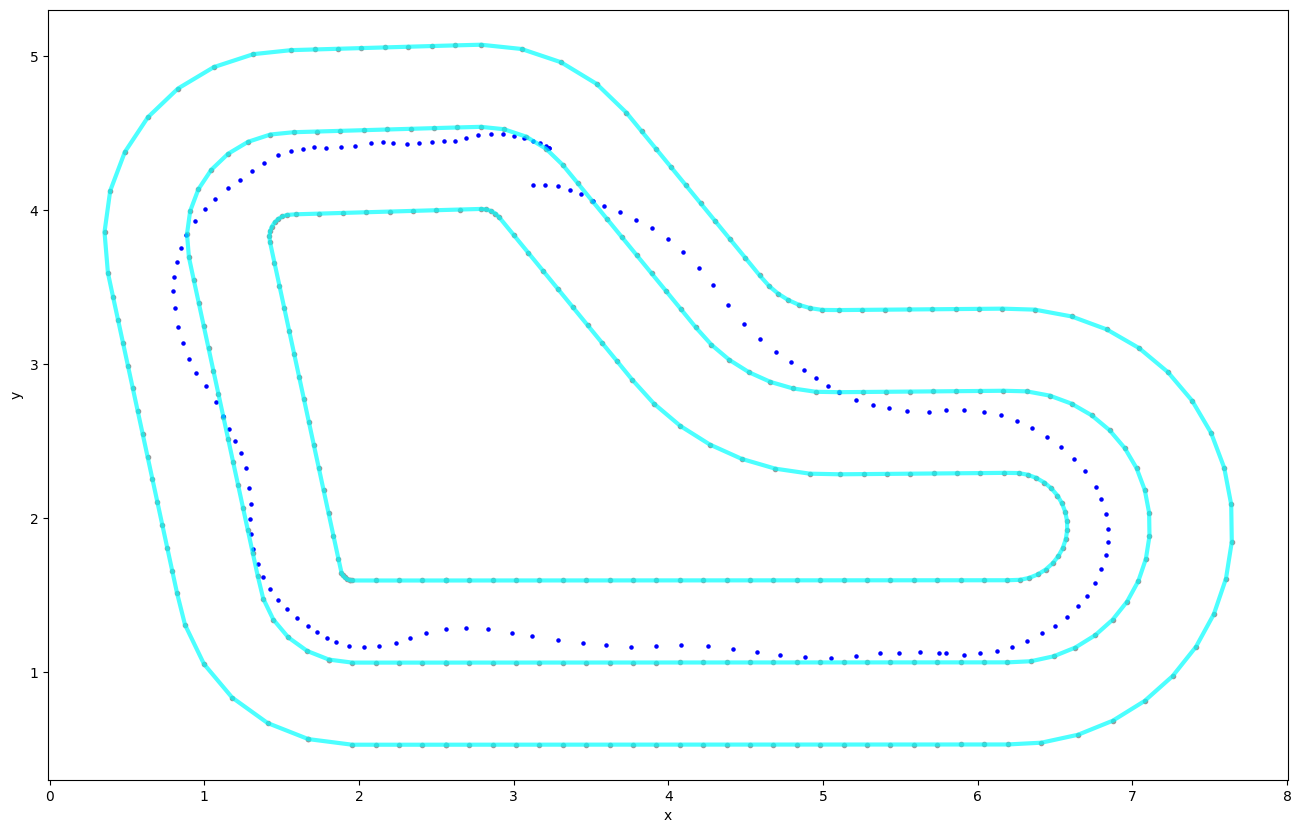

<Figure size 640x480 with 0 Axes>

In [113]:
try:
    if df.nunique(axis=0)['worker'] > 1:
        pu.plot_selected_laps([episode_id], df, track, section_to_plot="unique_episode")
    else: 
        pu.plot_selected_laps([episode_id], df, track)
except:
    print("Multiple workers not detected, assuming 1 worker")
    pu.plot_selected_laps([episode_id], df, track)

### Path taken in a particular iteration

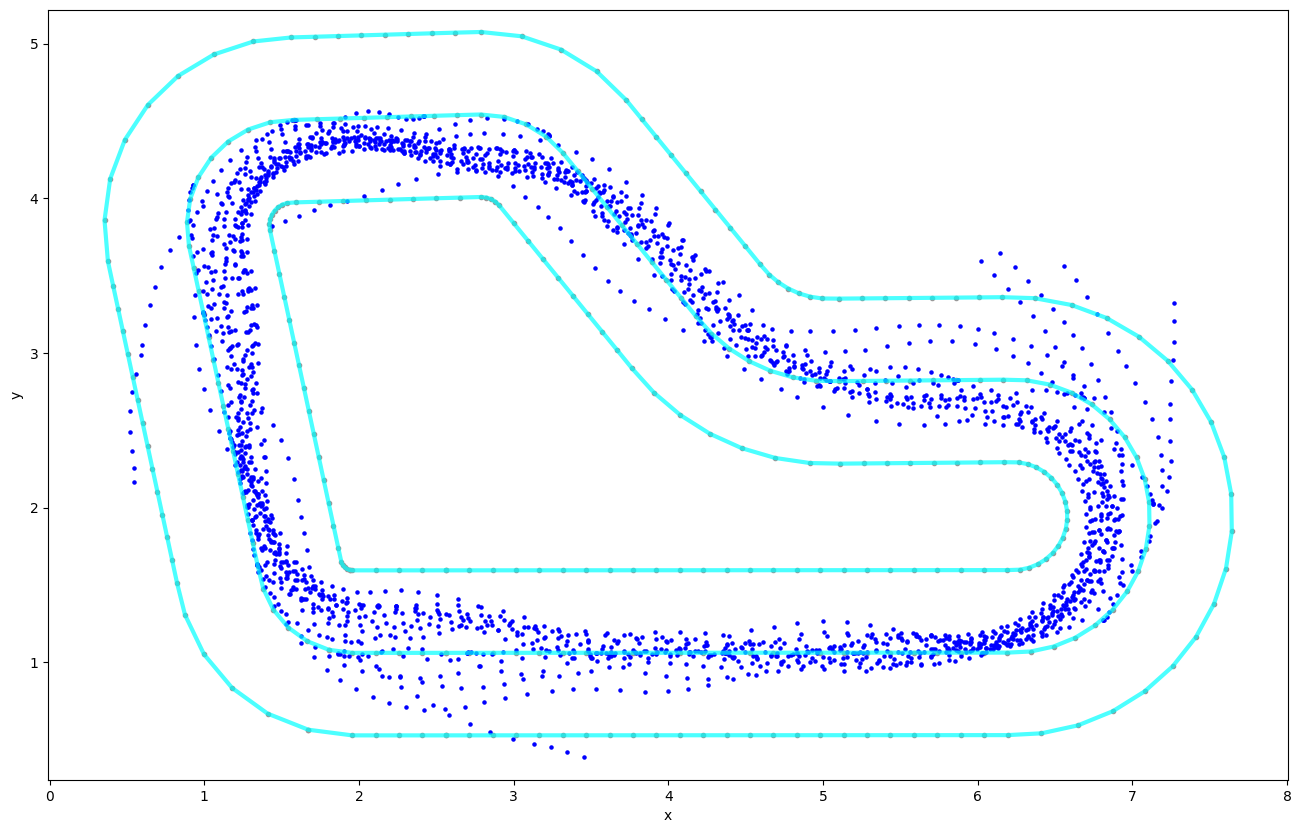

<Figure size 640x480 with 0 Axes>

In [114]:
iteration_id = 10

pu.plot_selected_laps([iteration_id], df, track, section_to_plot = 'iteration')